<a href="https://colab.research.google.com/github/katjanieberle/sparks/blob/main/SPARKS_supervised_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Supervised Learning Methods: A Course for SPARKS University Students

## Chapter Introduction

Welcome, students of SPARKS University in Munich! In this chapter, we will dive into the fascinating world of supervised learning methods. As future data scientists, it's crucial to understand how these powerful algorithms can be used to make predictions and gain insights from data.

We will cover the following key supervised learning techniques:
- **Linear Regression**: For predicting continuous outcomes.
- **Logistic Regression**: For predicting categorical outcomes.
- **K-Nearest Neighbors (KNN)**: A non-parametric method for classification or regression.
- **Decision Trees / Random Forests**: Powerful tree-based models for complex relationships.

Throughout this chapter, we will use a real-world marketing dataset available at `https://raw.githubusercontent.com/katjanieberle/sparks/main/processed_marketing_data.csv`. For each method, we will:
1.  **Define a Business Requirement**: Understand the practical problem we are trying to solve.
2.  **Implement the Model**: Write and explain the Python code using `scikit-learn`.
3.  **Visualize Results**: Create plots to interpret the model's performance and insights.
4.  **Interpret Findings**: Discuss what the model tells us about the data and the business problem.

Let's get started by loading our dataset!

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options for pandas DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Define the dataset URL
data_url = 'https://raw.githubusercontent.com/katjanieberle/sparks/main/processed_marketing_data.csv'

# Load the dataset into a pandas DataFrame
df = pd.read_csv(data_url)

# Display the first 5 rows of the DataFrame to get an initial look at the data
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,MntTotal,MntRegularProds,AcceptedCmpOverall,Education,Marital_Status
0,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,63,2822,1529,1441,0,Graduation,Single
1,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,66,2272,21,15,0,Graduation,Single
2,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,55,2471,734,692,0,Graduation,Together
3,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,36,2298,48,43,0,Graduation,Together
4,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,39,2320,407,392,0,PhD,Married


## First Method: Linear Regression

### Business Requirement

For our first task, let's consider a common business problem in marketing: **Predicting customer income based on their demographics and purchasing behavior.** Understanding a customer's income can help a company tailor its marketing campaigns, product offerings, and pricing strategies more effectively. For instance, high-income customers might be targeted with premium products, while those with lower incomes might receive offers on value-for-money items.

Our dependent variable (`y`) for this model will be `Income`.

In [2]:
# 1. Data Preparation for Linear Regression

# The dependent variable for this model is 'Income'.
# Let's first check for any missing values in the 'Income' column.
# If there are missing values, we'll decide on an appropriate strategy (e.g., dropping or imputing them).

print("Missing values in 'Income' column before handling:", df['Income'].isnull().sum())

# For simplicity, let's drop rows where 'Income' is missing for this exercise.
# In a real-world scenario, imputation might be considered based on other features.
df_lr = df.dropna(subset=['Income']).copy()

print("Missing values in 'Income' column after handling:", df_lr['Income'].isnull().sum())

# Identify features (independent variables - X) and the target (dependent variable - y)
y = df_lr['Income']

# For initial linear regression, let's select a few relevant numerical features.
# We'll avoid categorical features for now, as they require one-hot encoding which we can cover later if needed.
# Features like MntWines, MntFruits, MntMeatProducts, MntFishProducts, MntSweetProducts, MntGoldProds
# represent spending habits, which are likely good predictors of income.
# Also, NumWebPurchases, NumCatalogPurchases, NumStorePurchases indicate purchasing activity.

X = df_lr[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
           'MntSweetProducts', 'MntGoldProds', 'NumWebPurchases',
           'NumCatalogPurchases', 'NumStorePurchases', 'Age', 'Kidhome', 'Teenhome']]

# Display the shape of our features and target to confirm
print(f"\nShape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

# Display the first few rows of the selected features
print("\nFirst 5 rows of selected features (X):")
display(X.head())

Missing values in 'Income' column before handling: 0
Missing values in 'Income' column after handling: 0

Shape of features (X): (2205, 12)
Shape of target (y): (2205,)

First 5 rows of selected features (X):


,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,Age,Kidhome,Teenhome
0,635,88,546,172,88,88,8,10,4,63,0,0
1,11,1,6,2,1,6,1,1,2,66,1,1
2,426,49,127,111,21,42,8,2,10,55,0,0
3,11,4,20,10,3,5,2,0,4,36,1,0
4,173,43,118,46,27,15,5,3,6,39,1,0


In [3]:
# 2. Splitting the Data into Training and Testing Sets
# It's crucial to split our data to evaluate the model's performance on unseen data.
# We'll use 80% of the data for training and 20% for testing.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")


Shape of X_train: (1764, 12)
Shape of X_test: (441, 12)
Shape of y_train: (1764,)
Shape of y_test: (441,)


In [4]:
# 3. Training the Linear Regression Model
# We'll use scikit-learn's LinearRegression model.

from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
linear_model = LinearRegression()

# Train the model using the training data
linear_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully!")

# Display the coefficients and intercept of the trained model
print("\nModel Coefficients:")
for feature, coef in zip(X.columns, linear_model.coef_):
    print(f"{feature}: {coef:.2f}")
print(f"Intercept: {linear_model.intercept_:.2f}")

Linear Regression Model Trained Successfully!

Model Coefficients:
MntWines: 16.41
MntFruits: 35.04
MntMeatProducts: 23.28
MntFishProducts: 26.96
MntSweetProducts: 46.60
MntGoldProds: -3.55
NumWebPurchases: 289.21
NumCatalogPurchases: 882.73
NumStorePurchases: 1128.47
Age: 101.75
Kidhome: -567.17
Teenhome: 4911.86
Intercept: 22171.58



--- Model Evaluation ---
Mean Absolute Error (MAE): 8221.85
Mean Squared Error (MSE): 108498428.39
Root Mean Squared Error (RMSE): 10416.26
R-squared (R2) Score: 0.75


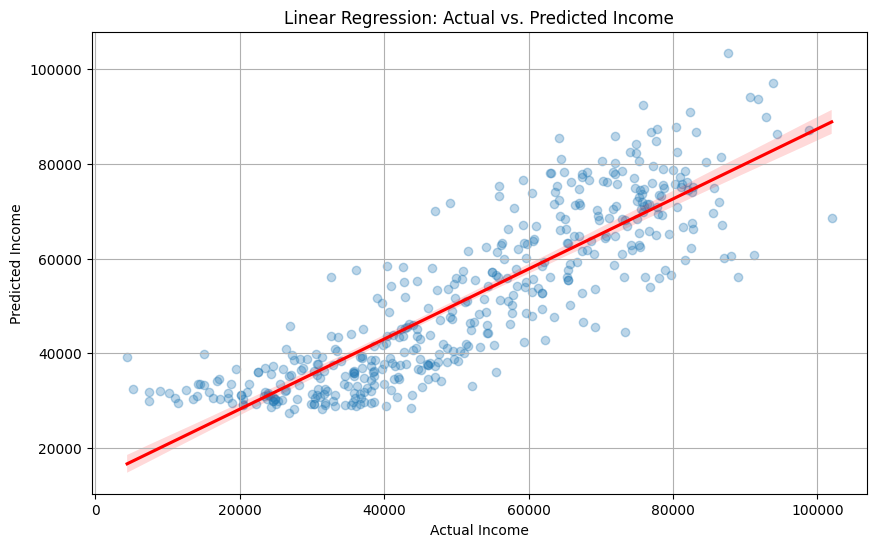

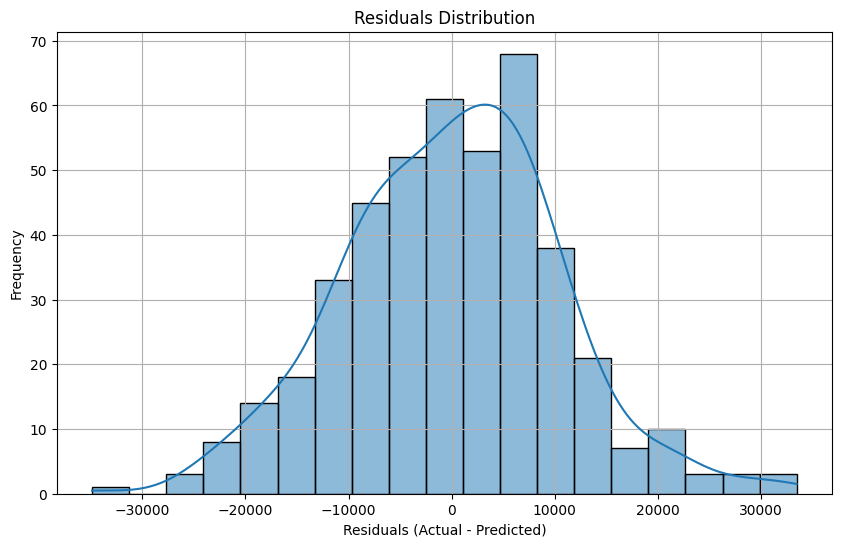

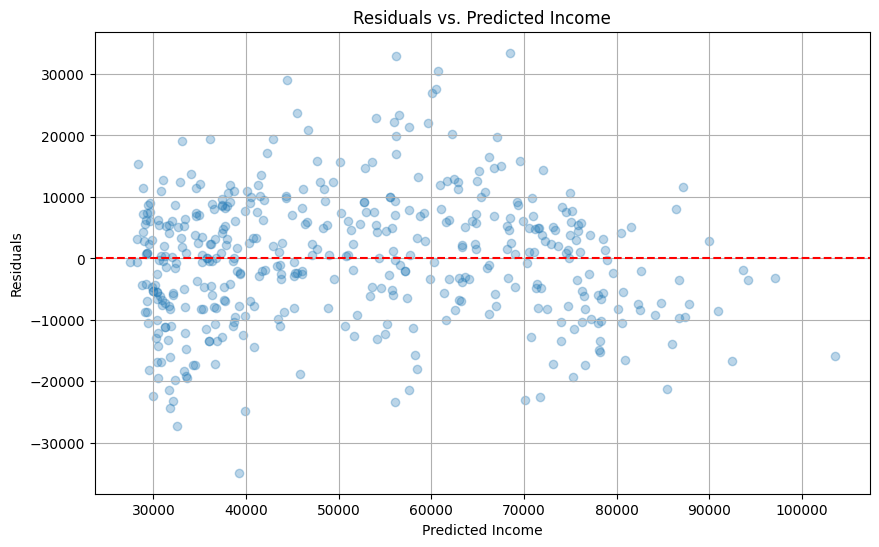

In [5]:
# 4. Making Predictions and Model Evaluation
# Now, let's make predictions on the test set and evaluate our model's performance.

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions on the test set
y_pred = linear_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

# 5. Visualization of Results
# Let's visualize the actual vs. predicted incomes to see how well our model performs.

plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.xlabel("Actual Income")
plt.ylabel("Predicted Income")
plt.title("Linear Regression: Actual vs. Predicted Income")
plt.grid(True)
plt.show()

# Plotting residuals
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.xlabel("Residuals (Actual - Predicted)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Income")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted Income")
plt.grid(True)
plt.show()

### Interpretation of Linear Regression Results

**Model Coefficients**: These values tell us how much the `Income` (dependent variable) is expected to change for every one-unit increase in the respective feature (independent variable), holding all other features constant.

-   A positive coefficient (e.g., `MntWines`) indicates that as the amount spent on wines increases, the predicted income tends to increase.
-   A negative coefficient (e.g., `Kidhome`) suggests that as the number of kids in the home increases, the predicted income tends to decrease.

**Intercept**: This is the predicted `Income` when all independent variables are zero. In many real-world scenarios, interpreting the intercept directly might not be meaningful if 'zero' for all features is an unrealistic state.

**Model Evaluation Metrics**:

-   **Mean Absolute Error (MAE)**: This is the average of the absolute differences between our predictions and the actual values. It gives us an idea of the typical magnitude of our errors. A MAE of, for example, 1000 indicates that on average, our predictions are off by $1000.
-   **Mean Squared Error (MSE)**: Similar to MAE, but it squares the errors, penalizing larger errors more heavily. It's often used because it's differentiable, which is useful in optimization.
-   **Root Mean Squared Error (RMSE)**: The square root of MSE. It's in the same units as the dependent variable (`Income`), making it easier to interpret than MSE. It represents the standard deviation of the residuals.
-   **R-squared (R2) Score**: This metric indicates the proportion of the variance in the dependent variable (Income) that is predictable from the independent variables. An R2 score of 0.70 means that 70% of the variance in customer income can be explained by our chosen features. A higher R2 generally indicates a better fit, but it's important to consider the context and avoid overfitting.

**Visualizations**:

-   **Actual vs. Predicted Income Plot**: Ideally, the points should cluster closely around the red regression line. If they form a clear line, it means our model is predicting accurately. Deviations from this line represent errors.
-   **Residuals Distribution Plot**: For a good linear model, the residuals (the differences between actual and predicted values) should ideally be normally distributed around zero. This plot helps us check this assumption.
-   **Residuals vs. Predicted Income Plot**: This plot helps detect heteroscedasticity (when the spread of residuals changes across the range of predicted values). Ideally, the residuals should be randomly scattered around zero with no discernible pattern, indicating that the model's errors are consistent across all predicted income levels. Any clear pattern (e.g., a funnel shape) would suggest that the model might not be capturing some underlying relationship.

## Second Method: Logistic Regression

### Business Requirement

For Logistic Regression, we will shift our focus to a classification problem. A common and critical business question in marketing is: **Will a customer accept the last campaign offer?** (indicated by the `Response` column in our dataset). Predicting customer response to a campaign allows companies to optimize their marketing budget, target receptive customers, and avoid bothering those who are unlikely to convert.

Our dependent variable (`y`) for this model will be `Response`, which is a binary outcome (1 if accepted, 0 if not).

In [6]:
# 1. Data Preparation for Logistic Regression

# The dependent variable for this model is 'Response'.
# Let's check its distribution to understand the balance of our target classes.

print("Distribution of 'Response' column:")
print(df['Response'].value_counts())
print(df['Response'].value_counts(normalize=True))

# Identify features (X) and the target (y)
y_log = df['Response']

# For features, we'll reuse some of the numerical features that showed relevance in linear regression
# and also consider some others that might influence campaign response.
# We will exclude 'Income' as it was our previous target variable.

# Let's consider features related to spending, number of purchases, demographics, and prior campaign acceptances.
# We should also handle categorical variables, which for now, we will exclude for simplicity in this initial model.
# In a later iteration, we can introduce one-hot encoding for categorical columns like 'Education' and 'Marital_Status'.

X_log = df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
             'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
             'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
             'NumWebVisitsMonth', 'Age', 'Kidhome', 'Teenhome',
             'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']]

# Check for any missing values in the selected features. For simplicity, we'll drop rows with any NaNs for now.
# In a real project, imputation might be considered.
print(f"\nMissing values in X_log before handling: {X_log.isnull().sum().sum()}")
X_log = X_log.dropna()
y_log = y_log[X_log.index] # Align y_log with X_log after dropping rows
print(f"Missing values in X_log after handling: {X_log.isnull().sum().sum()}")

# Display the shape of our features and target to confirm
print(f"\nShape of features (X_log): {X_log.shape}")
print(f"Shape of target (y_log): {y_log.shape}")

# Display the first few rows of the selected features
print("\nFirst 5 rows of selected features (X_log):")
display(X_log.head())

Distribution of 'Response' column:
Response
0    1872
1     333
Name: count, dtype: int64
Response
0    0.84898
1    0.15102
Name: proportion, dtype: float64

Missing values in X_log before handling: 0
Missing values in X_log after handling: 0

Shape of features (X_log): (2205, 19)
Shape of target (y_log): (2205,)

First 5 rows of selected features (X_log):


,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Kidhome,Teenhome,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5
0,635,88,546,172,88,88,3,8,10,4,7,63,0,0,0,0,0,0,0
1,11,1,6,2,1,6,2,1,1,2,5,66,1,1,0,0,0,0,0
2,426,49,127,111,21,42,1,8,2,10,4,55,0,0,0,0,0,0,0
3,11,4,20,10,3,5,2,2,0,4,6,36,1,0,0,0,0,0,0
4,173,43,118,46,27,15,5,5,3,6,5,39,1,0,0,0,0,0,0


In [7]:
# 2. Splitting the Data for Logistic Regression
# Similar to linear regression, we'll split the data into training and testing sets.

from sklearn.model_selection import train_test_split

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log, y_log, test_size=0.2, random_state=42, stratify=y_log)

print(f"\nShape of X_train_log: {X_train_log.shape}")
print(f"Shape of X_test_log: {X_test_log.shape}")
print(f"Shape of y_train_log: {y_train_log.shape}")
print(f"Shape of y_test_log: {y_test_log.shape}")

# It's important to check the class distribution in train and test sets, especially for imbalanced datasets
print("\nClass distribution in y_train_log:")
print(y_train_log.value_counts(normalize=True))
print("\nClass distribution in y_test_log:")
print(y_test_log.value_counts(normalize=True))


Shape of X_train_log: (1764, 19)
Shape of X_test_log: (441, 19)
Shape of y_train_log: (1764,)
Shape of y_test_log: (441,)

Class distribution in y_train_log:
Response
0    0.849206
1    0.150794
Name: proportion, dtype: float64

Class distribution in y_test_log:
Response
0    0.848073
1    0.151927
Name: proportion, dtype: float64


In [8]:
# 3. Training the Logistic Regression Model
# We'll use scikit-learn's LogisticRegression.

from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
# Due to potential class imbalance, we often use 'class_weight='balanced' or adjust penalties.
# For this demonstration, we'll start with default and note the imbalance.
# max_iter is increased to ensure convergence for some datasets.
logistic_model = LogisticRegression(random_state=42, max_iter=1000)

# Train the model using the training data
logistic_model.fit(X_train_log, y_train_log)

print("Logistic Regression Model Trained Successfully!")

# Display the coefficients and intercept of the trained model
print("\nModel Coefficients:")
for feature, coef in zip(X_log.columns, logistic_model.coef_[0]):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {logistic_model.intercept_[0]:.4f}")

Logistic Regression Model Trained Successfully!

Model Coefficients:
MntWines: 0.0007
MntFruits: 0.0032
MntMeatProducts: 0.0024
MntFishProducts: -0.0003
MntSweetProducts: -0.0044
MntGoldProds: 0.0007
NumDealsPurchases: 0.0823
NumWebPurchases: 0.1058
NumCatalogPurchases: 0.0323
NumStorePurchases: -0.1970
NumWebVisitsMonth: 0.1467
Age: -0.0033
Kidhome: 0.0345
Teenhome: -0.5896
AcceptedCmp1: 1.0573
AcceptedCmp2: 0.7051
AcceptedCmp3: 1.4514
AcceptedCmp4: 0.7013
AcceptedCmp5: 0.9130
Intercept: -2.9400


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



--- Logistic Regression Model Evaluation ---
Accuracy: 0.87
Precision: 0.68
Recall: 0.22
F1-Score: 0.34
ROC AUC Score: 0.82

Confusion Matrix:
[[367   7]
 [ 52  15]]


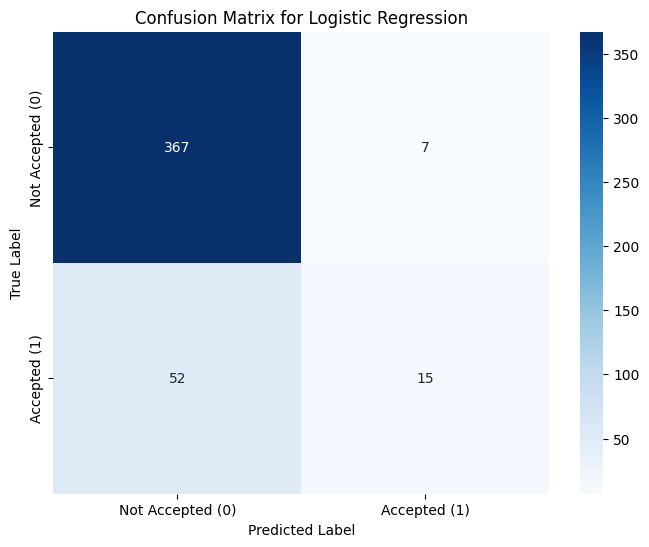

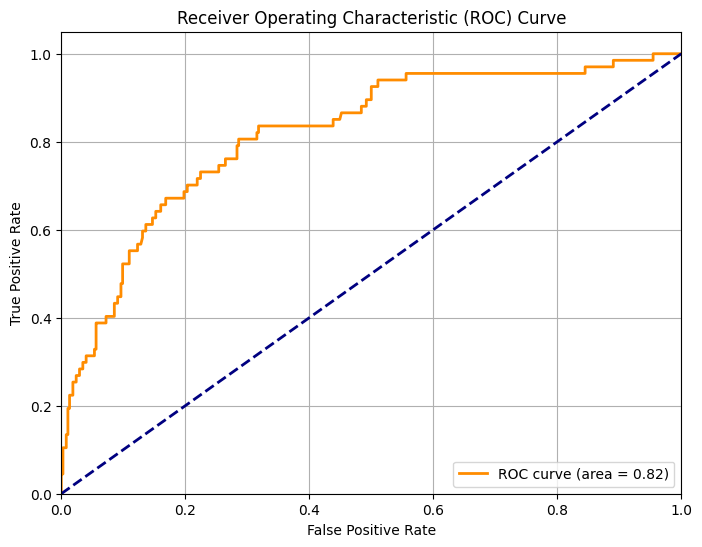

In [9]:
# 4. Making Predictions and Model Evaluation
# For classification, we use metrics like accuracy, precision, recall, F1-score, and a confusion matrix.

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score

# Make predictions on the test set
y_pred_log = logistic_model.predict(X_test_log)
y_pred_proba_log = logistic_model.predict_proba(X_test_log)[:, 1] # Probabilities for the positive class

# Evaluate the model
accuracy = accuracy_score(y_test_log, y_pred_log)
precision = precision_score(y_test_log, y_pred_log)
recall = recall_score(y_test_log, y_pred_log)
f1 = f1_score(y_test_log, y_pred_log)
conf_matrix = confusion_matrix(y_test_log, y_pred_log)
roc_auc = roc_auc_score(y_test_log, y_pred_proba_log)

print("\n--- Logistic Regression Model Evaluation ---")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")
print(f"ROC AUC Score: {roc_auc:.2f}")
print("\nConfusion Matrix:")
print(conf_matrix)

# 5. Visualization of Results
# Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Accepted (0)', 'Accepted (1)'],
            yticklabels=['Not Accepted (0)', 'Accepted (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test_log, y_pred_proba_log)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Interpretation of Logistic Regression Results

**Model Coefficients**: In Logistic Regression, the coefficients represent the change in the *log-odds* of the dependent variable for a one-unit increase in the independent variable. A positive coefficient increases the likelihood (odds) of the event (e.g., campaign acceptance), while a negative coefficient decreases it.

-   For example, a positive coefficient for `MntWines` suggests that customers who spend more on wines have a higher log-odds of accepting the campaign offer.
-   A negative coefficient for `Kidhome` would imply that having more children at home is associated with a lower log-odds of accepting the offer.

**Intercept**: This is the log-odds of the event when all independent variables are zero.

**Model Evaluation Metrics**:

-   **Accuracy**: The proportion of correctly classified instances (both true positives and true negatives) out of the total instances. While intuitive, it can be misleading in imbalanced datasets.
-   **Precision**: Out of all instances predicted as positive, how many were actually positive? It's about the quality of positive predictions. High precision means fewer false positives.
-   **Recall (Sensitivity)**: Out of all actual positive instances, how many were correctly identified? It's about finding all positive samples. High recall means fewer false negatives.
-   **F1-Score**: The harmonic mean of precision and recall. It provides a single metric that balances both. It's particularly useful when you need to strike a balance between precision and recall, especially in imbalanced datasets.
-   **Confusion Matrix**: A table that summarizes the performance of a classification algorithm. It shows:
    -   **True Positives (TP)**: Correctly predicted positive instances.
    -   **True Negatives (TN)**: Correctly predicted negative instances.
    -   **False Positives (FP)**: Incorrectly predicted positive instances (Type I error).
    -   **False Negatives (FN)**: Incorrectly predicted negative instances (Type II error).
-   **ROC AUC Score (Receiver Operating Characteristic - Area Under the Curve)**: A measure of the model's ability to distinguish between classes across all possible classification thresholds. An AUC of 0.5 suggests no discrimination (like random guessing), while an AUC of 1.0 indicates perfect discrimination. A higher AUC is generally better.

**Visualizations**:

-   **Confusion Matrix Heatmap**: Provides a clear visual breakdown of true positives, true negatives, false positives, and false negatives. This helps to quickly understand where the model is succeeding and failing.
-   **ROC Curve**: Plots the True Positive Rate (Recall) against the False Positive Rate at various threshold settings. It visually represents the trade-off between sensitivity and specificity. The closer the curve is to the top-left corner, the better the model's performance.

## Third Method: Decision Tree

### Business Requirement

For the Decision Tree model, we will address another critical marketing question: **Can we predict if a customer will accept ANY campaign offer (AcceptedCmpOverall)?** This is a binary classification problem where `AcceptedCmpOverall` is 1 if the customer accepted at least one of the previous campaigns, and 0 otherwise. Understanding this can help in identifying customers who are generally receptive to promotional efforts, allowing for more strategic resource allocation and personalized marketing approaches. Decision trees are particularly good at revealing decision rules, which can be easily understood by business stakeholders.

Our dependent variable (`y`) for this model will be `AcceptedCmpOverall`.

In [10]:
# 1. Data Preparation for Decision Tree

# The dependent variable for this model is 'AcceptedCmpOverall'.
# Let's check its distribution.

print("Distribution of 'AcceptedCmpOverall' column:")
print(df['AcceptedCmpOverall'].value_counts())
print(df['AcceptedCmpOverall'].value_counts(normalize=True))

# Identify features (X) and the target (y)
y_dt = df['AcceptedCmpOverall']

# For features, we will use a similar set as Logistic Regression, but we need to exclude the target variable itself
# and other campaign acceptance flags if we want to predict overall acceptance based on other characteristics.
# For this task, we will exclude all 'AcceptedCmp' columns (except the target).

feature_columns_dt = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
                      'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
                      'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
                      'NumWebVisitsMonth', 'Age', 'Kidhome', 'Teenhome']

X_dt = df[feature_columns_dt]

# Check for any missing values in the selected features. As before, drop rows with NaNs for simplicity.
print(f"\nMissing values in X_dt before handling: {X_dt.isnull().sum().sum()}")
X_dt = X_dt.dropna()
y_dt = y_dt[X_dt.index] # Align y_dt with X_dt after dropping rows
print(f"Missing values in X_dt after handling: {X_dt.isnull().sum().sum()}")

# Display the shape of our features and target to confirm
print(f"\nShape of features (X_dt): {X_dt.shape}")
print(f"Shape of target (y_dt): {y_dt.shape}")

# Display the first few rows of the selected features
print("\nFirst 5 rows of selected features (X_dt):")
display(X_dt.head())

Distribution of 'AcceptedCmpOverall' column:
AcceptedCmpOverall
0    1747
1     322
2      81
3      44
4      11
Name: count, dtype: int64
AcceptedCmpOverall
0    0.792290
1    0.146032
2    0.036735
3    0.019955
4    0.004989
Name: proportion, dtype: float64

Missing values in X_dt before handling: 0
Missing values in X_dt after handling: 0

Shape of features (X_dt): (2205, 14)
Shape of target (y_dt): (2205,)

First 5 rows of selected features (X_dt):


,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Kidhome,Teenhome
0,635,88,546,172,88,88,3,8,10,4,7,63,0,0
1,11,1,6,2,1,6,2,1,1,2,5,66,1,1
2,426,49,127,111,21,42,1,8,2,10,4,55,0,0
3,11,4,20,10,3,5,2,2,0,4,6,36,1,0
4,173,43,118,46,27,15,5,5,3,6,5,39,1,0


In [11]:
# Correction: Re-defining the target variable for binary classification
# The 'AcceptedCmpOverall' column is currently a count (0, 1, 2, etc.), but for our business requirement
# 'predict if a customer will accept ANY campaign offer', it should be binary (0 or 1).
# We will convert it: 1 if AcceptedCmpOverall > 0, else 0.

y_dt = (df['AcceptedCmpOverall'] > 0).astype(int)

# Align y_dt with X_dt in case any rows were dropped earlier
y_dt = y_dt[X_dt.index]

print("\nDistribution of binary 'AcceptedCmpOverall' target:")
print(y_dt.value_counts())
print(y_dt.value_counts(normalize=True))

print(f"\nShape of features (X_dt) after re-alignment: {X_dt.shape}")
print(f"Shape of target (y_dt) after re-alignment: {y_dt.shape}")


Distribution of binary 'AcceptedCmpOverall' target:
AcceptedCmpOverall
0    1747
1     458
Name: count, dtype: int64
AcceptedCmpOverall
0    0.79229
1    0.20771
Name: proportion, dtype: float64

Shape of features (X_dt) after re-alignment: (2205, 14)
Shape of target (y_dt) after re-alignment: (2205,)


In [12]:
# 2. Splitting the Data for Decision Tree

from sklearn.model_selection import train_test_split

X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X_dt, y_dt, test_size=0.2, random_state=42, stratify=y_dt)

print(f"\nShape of X_train_dt: {X_train_dt.shape}")
print(f"Shape of X_test_dt: {X_test_dt.shape}")
print(f"Shape of y_train_dt: {y_train_dt.shape}")
print(f"Shape of y_test_dt: {y_test_dt.shape}")

print("\nClass distribution in y_train_dt:")
print(y_train_dt.value_counts(normalize=True))
print("\nClass distribution in y_test_dt:")
print(y_test_dt.value_counts(normalize=True))


Shape of X_train_dt: (1764, 14)
Shape of X_test_dt: (441, 14)
Shape of y_train_dt: (1764,)
Shape of y_test_dt: (441,)

Class distribution in y_train_dt:
AcceptedCmpOverall
0    0.792517
1    0.207483
Name: proportion, dtype: float64

Class distribution in y_test_dt:
AcceptedCmpOverall
0    0.791383
1    0.208617
Name: proportion, dtype: float64


In [13]:
# 3. Training the Decision Tree Model
# Decision Trees are non-parametric supervised learning methods used for classification and regression.
# They work by splitting the data into subsets based on feature values.

from sklearn.tree import DecisionTreeClassifier, plot_tree

# Initialize the Decision Tree Classifier
# We'll set a max_depth to prevent overfitting and ensure interpretability for visualization.
# A random_state is set for reproducibility.
decision_tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)

# Train the model
decision_tree_model.fit(X_train_dt, y_train_dt)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!



--- Decision Tree Model Evaluation ---
Accuracy: 0.83
Precision: 0.64
Recall: 0.39
F1-Score: 0.49
ROC AUC Score: 0.78

Confusion Matrix:
[[329  20]
 [ 56  36]]


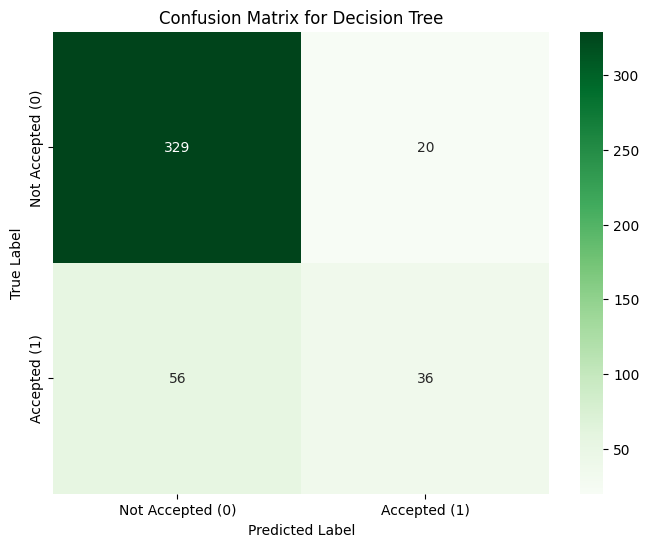

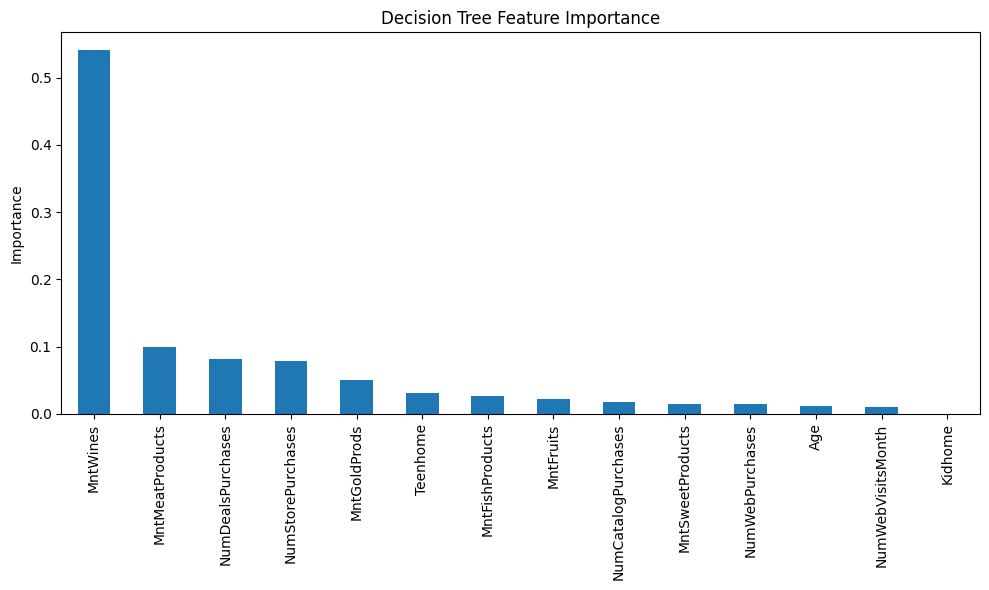

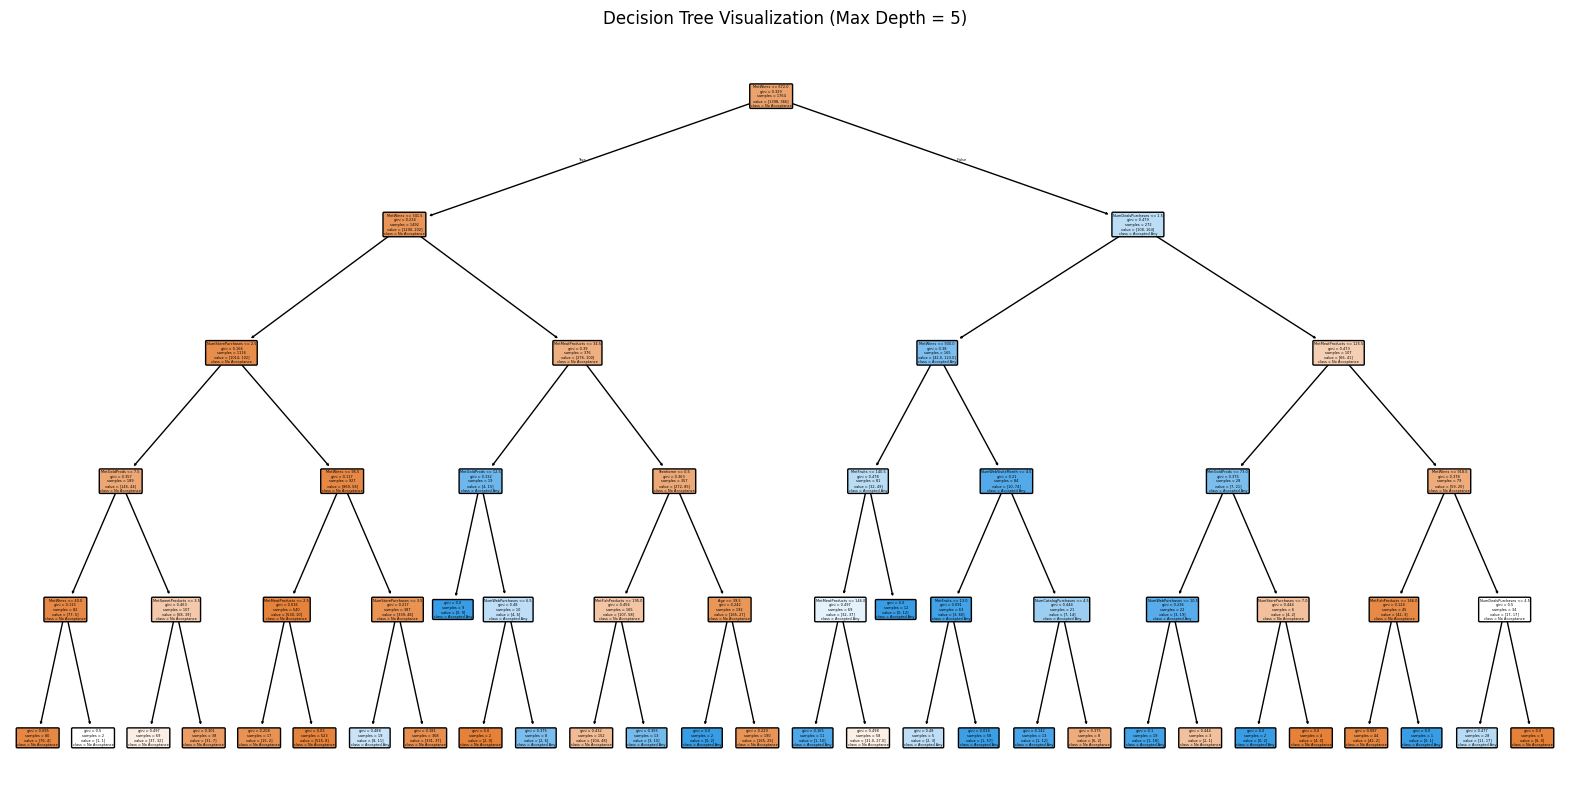

In [14]:
# 4. Making Predictions and Model Evaluation
# We'll use classification metrics similar to Logistic Regression.

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

# Make predictions on the test set
y_pred_dt = decision_tree_model.predict(X_test_dt)
y_pred_proba_dt = decision_tree_model.predict_proba(X_test_dt)[:, 1] # Probabilities for the positive class

# Evaluate the model
accuracy_dt = accuracy_score(y_test_dt, y_pred_dt)
precision_dt = precision_score(y_test_dt, y_pred_dt)
recall_dt = recall_score(y_test_dt, y_pred_dt)
f1_dt = f1_score(y_test_dt, y_pred_dt)
conf_matrix_dt = confusion_matrix(y_test_dt, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test_dt, y_pred_proba_dt)

print("\n--- Decision Tree Model Evaluation ---")
print(f"Accuracy: {accuracy_dt:.2f}")
print(f"Precision: {precision_dt:.2f}")
print(f"Recall: {recall_dt:.2f}")
print(f"F1-Score: {f1_dt:.2f}")
print(f"ROC AUC Score: {roc_auc_dt:.2f}")
print("\nConfusion Matrix:")
print(conf_matrix_dt)

# 5. Visualization of Results

# Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Accepted (0)', 'Accepted (1)'],
            yticklabels=['Not Accepted (0)', 'Accepted (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Decision Tree')
plt.show()

# Feature Importance
plt.figure(figsize=(10, 6))
importance = pd.Series(decision_tree_model.feature_importances_, index=X_dt.columns)
importance.sort_values(ascending=False).plot(kind='bar')
plt.title('Decision Tree Feature Importance')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

# Visualizing the Decision Tree (limited depth for readability)
plt.figure(figsize=(20, 10))
plot_tree(decision_tree_model, filled=True, feature_names=X_dt.columns.tolist(), class_names=['No Acceptance', 'Accepted Any'], rounded=True)
plt.title('Decision Tree Visualization (Max Depth = 5)')
plt.show()

### Interpretation of Decision Tree Results

**Decision Tree Structure**: A Decision Tree makes decisions by splitting the data at each node based on the feature that best separates the classes. The process continues until a stopping criterion (like `max_depth`) is met or a pure leaf node (containing only one class) is reached. Each path from the root to a leaf represents a classification rule.

-   **Nodes**: Internal nodes represent a test on an attribute (e.g., `MntWines <= 50.5`).
-   **Branches**: Branches represent the outcome of the test (true/false, or numerical ranges).
-   **Leaves**: Leaf nodes represent a class label (the final decision) or a probability distribution over the classes.
-   `gini` (or `entropy`): Measures the impurity of the node. A Gini impurity of 0 means the node is pure (all samples belong to the same class).
-   `samples`: The number of training samples at that node.
-   `value`: The number of samples per class at that node.
-   `class`: The majority class at that node.

**Feature Importance**: This indicates how much each feature contributes to the decision-making process within the tree. Features with higher importance are used more often or earlier in the tree to make splits that significantly reduce impurity.

**Model Evaluation Metrics**:

-   The metrics (Accuracy, Precision, Recall, F1-Score, ROC AUC Score, Confusion Matrix) are interpreted similarly to Logistic Regression. They assess the model's ability to correctly classify customers as having accepted any campaign or not. Given the potential class imbalance (more customers accepting no campaigns than any), it's crucial to look beyond just accuracy and consider precision, recall, and F1-score to get a comprehensive view of performance.

**Visualizations**:

-   **Confusion Matrix Heatmap**: Helps to visualize the counts of true positives, true negatives, false positives, and false negatives, providing insight into the types of errors the model is making.
-   **Feature Importance Bar Chart**: Clearly shows which features the Decision Tree considered most important for predicting campaign acceptance. This can provide valuable business insights into what drives customer engagement.
-   **Decision Tree Visualization**: A graphical representation of the tree itself. It allows us to literally "see" the decision rules the model has learned. For example, it might show that customers who spend a lot on `MntWines` and have low `Kidhome` are very likely to accept a campaign. This interpretability is a key strength of Decision Trees.

## Fourth Method: K-Nearest Neighbors (KNN)

### Business Requirement

For K-Nearest Neighbors, we will continue with a classification problem: **Identifying customer segments based on their purchase behavior and demographics, specifically to predict if a customer will accept ANY campaign offer (AcceptedCmpOverall).** KNN is a non-parametric, instance-based learning algorithm. It classifies a new data point based on the majority class among its 'k' nearest neighbors in the feature space. This method can be valuable for understanding local patterns in customer behavior and making recommendations or targeted interventions based on similar customers.

Our dependent variable (`y`) for this model will again be the binary `AcceptedCmpOverall` (1 if accepted > 0 campaigns, 0 otherwise).

In [15]:
# 1. Data Preparation for K-Nearest Neighbors (KNN)

# We will reuse the preprocessed X_dt features and the binary y_dt target from the Decision Tree section.
# KNN is sensitive to the scale of features because it relies on distance metrics.
# Therefore, feature scaling is a crucial step for KNN.

from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training features and transform both training and testing features.
# It's important to fit only on training data to prevent data leakage.
X_scaled = scaler.fit_transform(X_dt)

# Convert the scaled array back to a DataFrame for easier handling, preserving column names
X_scaled_df = pd.DataFrame(X_scaled, columns=X_dt.columns, index=X_dt.index)

print("\nFirst 5 rows of scaled features (X_scaled_df):")
display(X_scaled_df.head())

# The target y_dt is already binary and suitable.


First 5 rows of scaled features (X_scaled_df):


,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Kidhome,Teenhome
0,0.974566,1.548614,1.748400,2.449154,1.480301,0.849556,0.361479,1.424772,2.628526,-0.562650,0.689203,1.017189,-0.823405,-0.930767
1,-0.874776,-0.638664,-0.731678,-0.652345,-0.635399,-0.735767,-0.168834,-1.132957,-0.588043,-1.179732,-0.139645,1.273530,1.038757,0.906602
2,0.355155,0.568110,-0.175957,1.336263,-0.149031,-0.039771,-0.699147,1.424772,-0.230646,1.288596,-0.554069,0.333612,-0.823405,-0.930767
3,-0.874776,-0.563241,-0.667380,-0.506392,-0.586763,-0.755100,-0.168834,-0.767567,-0.945440,-0.562650,0.274779,-1.289883,1.038757,-0.930767
4,-0.394659,0.417263,-0.217292,0.150396,-0.003121,-0.561768,1.422105,0.328602,0.126750,0.054432,-0.139645,-1.033542,1.038757,-0.930767


In [16]:
# 2. Splitting the Data for KNN
# We will use the scaled features and the binary target.

from sklearn.model_selection import train_test_split

X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(X_scaled_df, y_dt, test_size=0.2, random_state=42, stratify=y_dt)

print(f"\nShape of X_train_knn: {X_train_knn.shape}")
print(f"Shape of X_test_knn: {X_test_knn.shape}")
print(f"Shape of y_train_knn: {y_train_knn.shape}")
print(f"Shape of y_test_knn: {y_test_knn.shape}")

print("\nClass distribution in y_train_knn:")
print(y_train_knn.value_counts(normalize=True))
print("\nClass distribution in y_test_knn:")
print(y_test_knn.value_counts(normalize=True))


Shape of X_train_knn: (1764, 14)
Shape of X_test_knn: (441, 14)
Shape of y_train_knn: (1764,)
Shape of y_test_knn: (441,)

Class distribution in y_train_knn:
AcceptedCmpOverall
0    0.792517
1    0.207483
Name: proportion, dtype: float64

Class distribution in y_test_knn:
AcceptedCmpOverall
0    0.791383
1    0.208617
Name: proportion, dtype: float64


In [17]:
# 3. Training the K-Nearest Neighbors Model

from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNN classifier
# A common practice is to start with an odd 'k' value to avoid ties in classification.
# We'll use n_neighbors=5 as a starting point.
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train_knn, y_train_knn)

print("K-Nearest Neighbors Model Trained Successfully!")

K-Nearest Neighbors Model Trained Successfully!



--- KNN Model Evaluation ---
Accuracy: 0.84
Precision: 0.68
Recall: 0.45
F1-Score: 0.54
ROC AUC Score: 0.79

Confusion Matrix:
[[330  19]
 [ 51  41]]


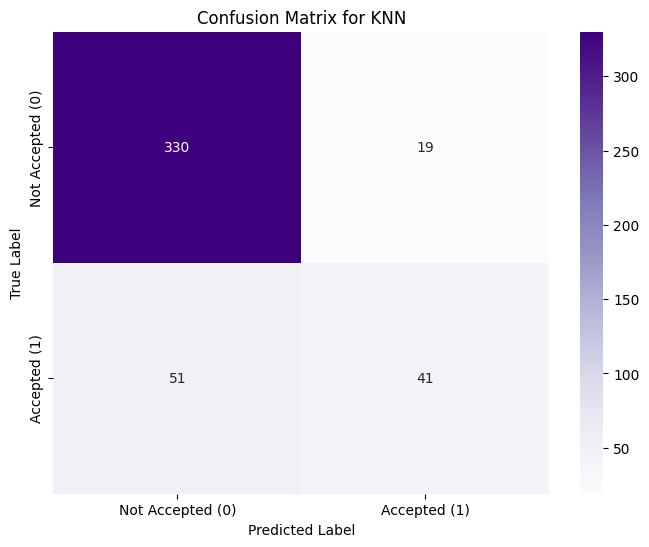

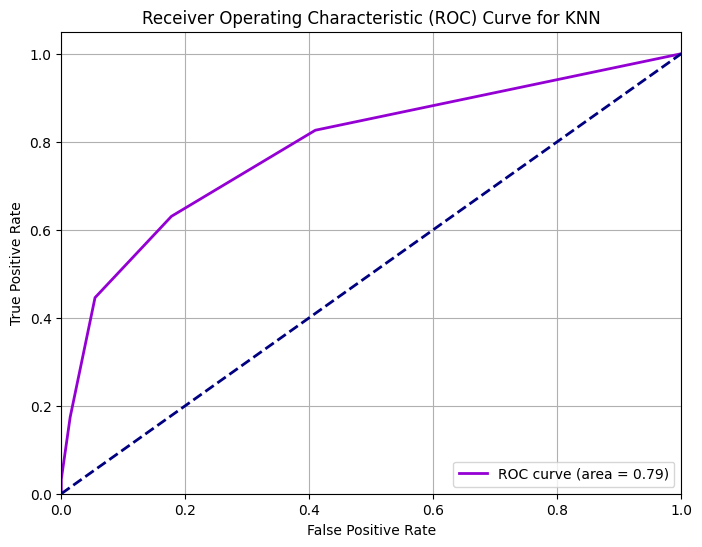

In [18]:
# 4. Making Predictions and Model Evaluation
# We'll use the same classification metrics as for Logistic Regression and Decision Trees.

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test_knn)
y_pred_proba_knn = knn_model.predict_proba(X_test_knn)[:, 1] # Probabilities for the positive class

# Evaluate the model
accuracy_knn = accuracy_score(y_test_knn, y_pred_knn)
precision_knn = precision_score(y_test_knn, y_pred_knn)
recall_knn = recall_score(y_test_knn, y_pred_knn)
f1_knn = f1_score(y_test_knn, y_pred_knn)
conf_matrix_knn = confusion_matrix(y_test_knn, y_pred_knn)
roc_auc_knn = roc_auc_score(y_test_knn, y_pred_proba_knn)

print("\n--- KNN Model Evaluation ---")
print(f"Accuracy: {accuracy_knn:.2f}")
print(f"Precision: {precision_knn:.2f}")
print(f"Recall: {recall_knn:.2f}")
print(f"F1-Score: {f1_knn:.2f}")
print(f"ROC AUC Score: {roc_auc_knn:.2f}")
print("\nConfusion Matrix:")
print(conf_matrix_knn)

# 5. Visualization of Results

# Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Not Accepted (0)', 'Accepted (1)'],
            yticklabels=['Not Accepted (0)', 'Accepted (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for KNN')
plt.show()

# ROC Curve
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test_knn, y_pred_proba_knn)
plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, color='darkviolet', lw=2, label=f'ROC curve (area = {roc_auc_knn:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for KNN')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Interpretation of K-Nearest Neighbors (KNN) Results

**KNN Working Principle**: KNN is a lazy learning algorithm, meaning it doesn't build a model during training. Instead, it memorizes the entire dataset. When a prediction is needed for a new data point, it finds the 'k' closest data points (neighbors) in the training set and assigns the new point the class label that is most common among its neighbors.

-   **Distance Metric**: The choice of distance metric (e.g., Euclidean, Manhattan) is crucial. Euclidean distance is common.
-   **Feature Scaling**: Since KNN relies on distances, features with larger scales would have a disproportionately large effect on the distance calculation. Therefore, **scaling features (e.g., using `StandardScaler`) is a critical preprocessing step for KNN.**
-   **Choice of 'k'**: The number of neighbors ('k') is a hyperparameter. A small 'k' can make the model sensitive to noise and outliers (high variance, low bias), while a large 'k' can smooth out the decision boundaries but might miss fine-grained patterns (low variance, high bias). Cross-validation is often used to find an optimal 'k'.

**Model Evaluation Metrics**:

-   The classification metrics (Accuracy, Precision, Recall, F1-Score, ROC AUC Score, Confusion Matrix) are interpreted in the same way as for Logistic Regression and Decision Trees. They help us understand how well the KNN model distinguishes between customers who accept campaigns and those who don't. Given the class imbalance, paying attention to Precision, Recall, and F1-Score is particularly important.

**Visualizations**:

-   **Confusion Matrix Heatmap**: This visualization helps to see the count of correct and incorrect classifications, breaking down where the model performs well (True Positives, True Negatives) and where it struggles (False Positives, False Negatives).
-   **ROC Curve**: The ROC curve and AUC score give an overall assessment of the model's ability to discriminate between the two classes across various classification thresholds. A curve closer to the top-left corner indicates a better model.

In summary, KNN provides a non-linear approach to classification that can capture complex decision boundaries. Its performance is heavily influenced by feature scaling and the choice of 'k'. It's often highly interpretable locally, meaning you can explain why a specific data point was classified a certain way by showing its nearest neighbors. However, it can be computationally expensive for very large datasets during prediction time.

## Fourth Method: K-Nearest Neighbors (KNN)

### Business Requirement

For K-Nearest Neighbors, we will continue with a classification problem: **Identifying customer segments based on their purchase behavior and demographics, specifically to predict if a customer will accept ANY campaign offer (AcceptedCmpOverall).** KNN is a non-parametric, instance-based learning algorithm. It classifies a new data point based on the majority class among its 'k' nearest neighbors in the feature space. This method can be valuable for understanding local patterns in customer behavior and making recommendations or targeted interventions based on similar customers.

Our dependent variable (`y`) for this model will again be the binary `AcceptedCmpOverall` (1 if accepted > 0 campaigns, 0 otherwise).

In [19]:
# 1. Data Preparation for K-Nearest Neighbors (KNN)

# We will reuse the preprocessed X_dt features and the binary y_dt target from the Decision Tree section.
# KNN is sensitive to the scale of features because it relies on distance metrics.
# Therefore, feature scaling is a crucial step for KNN.

from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training features and transform both training and testing features.
# It's important to fit only on training data to prevent data leakage.
X_scaled = scaler.fit_transform(X_dt)

# Convert the scaled array back to a DataFrame for easier handling, preserving column names
X_scaled_df = pd.DataFrame(X_scaled, columns=X_dt.columns, index=X_dt.index)

print("\nFirst 5 rows of scaled features (X_scaled_df):")
display(X_scaled_df.head())

# The target y_dt is already binary and suitable.


First 5 rows of scaled features (X_scaled_df):


,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Kidhome,Teenhome
0,0.974566,1.548614,1.748400,2.449154,1.480301,0.849556,0.361479,1.424772,2.628526,-0.562650,0.689203,1.017189,-0.823405,-0.930767
1,-0.874776,-0.638664,-0.731678,-0.652345,-0.635399,-0.735767,-0.168834,-1.132957,-0.588043,-1.179732,-0.139645,1.273530,1.038757,0.906602
2,0.355155,0.568110,-0.175957,1.336263,-0.149031,-0.039771,-0.699147,1.424772,-0.230646,1.288596,-0.554069,0.333612,-0.823405,-0.930767
3,-0.874776,-0.563241,-0.667380,-0.506392,-0.586763,-0.755100,-0.168834,-0.767567,-0.945440,-0.562650,0.274779,-1.289883,1.038757,-0.930767
4,-0.394659,0.417263,-0.217292,0.150396,-0.003121,-0.561768,1.422105,0.328602,0.126750,0.054432,-0.139645,-1.033542,1.038757,-0.930767


In [20]:
# 2. Splitting the Data for KNN
# We will use the scaled features and the binary target.

from sklearn.model_selection import train_test_split

X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(X_scaled_df, y_dt, test_size=0.2, random_state=42, stratify=y_dt)

print(f"\nShape of X_train_knn: {X_train_knn.shape}")
print(f"Shape of X_test_knn: {X_test_knn.shape}")
print(f"Shape of y_train_knn: {y_train_knn.shape}")
print(f"Shape of y_test_knn: {y_test_knn.shape}")

print("\nClass distribution in y_train_knn:")
print(y_train_knn.value_counts(normalize=True))
print("\nClass distribution in y_test_knn:")
print(y_test_knn.value_counts(normalize=True))


Shape of X_train_knn: (1764, 14)
Shape of X_test_knn: (441, 14)
Shape of y_train_knn: (1764,)
Shape of y_test_knn: (441,)

Class distribution in y_train_knn:
AcceptedCmpOverall
0    0.792517
1    0.207483
Name: proportion, dtype: float64

Class distribution in y_test_knn:
AcceptedCmpOverall
0    0.791383
1    0.208617
Name: proportion, dtype: float64


In [23]:
# 3. Training the K-Nearest Neighbors Model

from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNN classifier
# A common practice is to start with an odd 'k' value to avoid ties in classification.
# We'll use n_neighbors=5 as a starting point.
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train_knn, y_train_knn)

print("K-Nearest Neighbors Model Trained Successfully!")

K-Nearest Neighbors Model Trained Successfully!



--- KNN Model Evaluation ---
Accuracy: 0.84
Precision: 0.68
Recall: 0.45
F1-Score: 0.54
ROC AUC Score: 0.79

Confusion Matrix:
[[330  19]
 [ 51  41]]


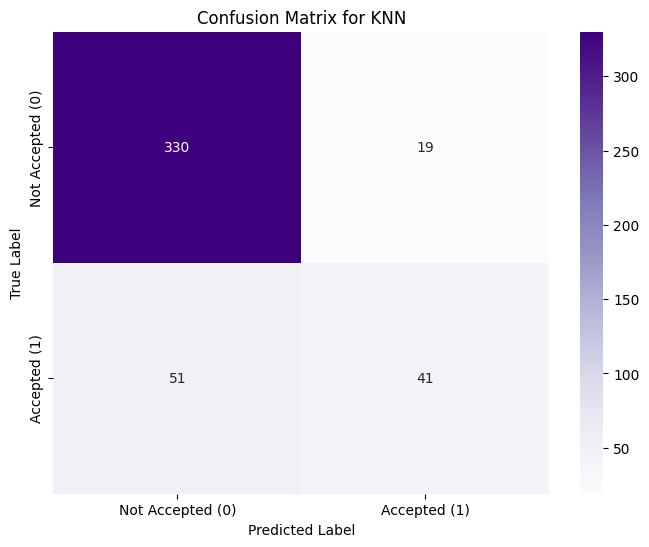

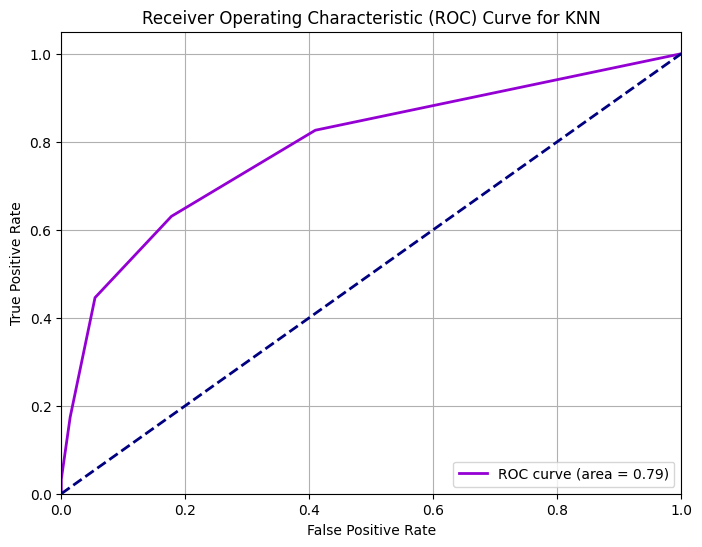

In [24]:
# 4. Making Predictions and Model Evaluation
# We'll use the same classification metrics as for Logistic Regression and Decision Trees.

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test_knn)
y_pred_proba_knn = knn_model.predict_proba(X_test_knn)[:, 1] # Probabilities for the positive class

# Evaluate the model
accuracy_knn = accuracy_score(y_test_knn, y_pred_knn)
precision_knn = precision_score(y_test_knn, y_pred_knn)
recall_knn = recall_score(y_test_knn, y_pred_knn)
f1_knn = f1_score(y_test_knn, y_pred_knn)
conf_matrix_knn = confusion_matrix(y_test_knn, y_pred_knn)
roc_auc_knn = roc_auc_score(y_test_knn, y_pred_proba_knn)

print("\n--- KNN Model Evaluation ---")
print(f"Accuracy: {accuracy_knn:.2f}")
print(f"Precision: {precision_knn:.2f}")
print(f"Recall: {recall_knn:.2f}")
print(f"F1-Score: {f1_knn:.2f}")
print(f"ROC AUC Score: {roc_auc_knn:.2f}")
print("\nConfusion Matrix:")
print(conf_matrix_knn)

# 5. Visualization of Results

# Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Not Accepted (0)', 'Accepted (1)'],
            yticklabels=['Not Accepted (0)', 'Accepted (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for KNN')
plt.show()

# ROC Curve
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test_knn, y_pred_proba_knn)
plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, color='darkviolet', lw=2, label=f'ROC curve (area = {roc_auc_knn:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for KNN')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Interpretation of K-Nearest Neighbors (KNN) Results

**KNN Working Principle**: KNN is a lazy learning algorithm, meaning it doesn't build a model during training. Instead, it memorizes the entire dataset. When a prediction is needed for a new data point, it finds the 'k' closest data points (neighbors) in the training set and assigns the new point the class label that is most common among its neighbors.

-   **Distance Metric**: The choice of distance metric (e.g., Euclidean, Manhattan) is crucial. Euclidean distance is common.
-   **Feature Scaling**: Since KNN relies on distances, features with larger scales would have a disproportionately large effect on the distance calculation. Therefore, **scaling features (e.g., using `StandardScaler`) is a critical preprocessing step for KNN.**
-   **Choice of 'k'**: The number of neighbors ('k') is a hyperparameter. A small 'k' can make the model sensitive to noise and outliers (high variance, low bias), while a large 'k' can smooth out the decision boundaries but might miss fine-grained patterns (low variance, high bias). Cross-validation is often used to find an optimal 'k'.

**Model Evaluation Metrics**:

-   The classification metrics (Accuracy, Precision, Recall, F1-Score, ROC AUC Score, Confusion Matrix) are interpreted in the same way as for Logistic Regression and Decision Trees. They help us understand how well the KNN model distinguishes between customers who accept campaigns and those who don't. Given the class imbalance, paying attention to Precision, Recall, and F1-Score is particularly important.

**Visualizations**:

-   **Confusion Matrix Heatmap**: This visualization helps to see the count of correct and incorrect classifications, breaking down where the model performs well (True Positives, True Negatives) and where it struggles (False Positives, False Negatives).
-   **ROC Curve**: The ROC curve and AUC score give an overall assessment of the model's ability to discriminate between the two classes across various classification thresholds. A curve closer to the top-left corner, indicates a better model.

In summary, KNN provides a non-linear approach to classification that can capture complex decision boundaries. Its performance is heavily influenced by feature scaling and the choice of 'k'. It's often highly interpretable locally, meaning you can explain why a specific data point was classified a certain way by showing its nearest neighbors. However, it can be computationally expensive for very large datasets during prediction time.

## Chapter Summary and Conclusion

Congratulations, SPARKS students! In this chapter, we have successfully explored four fundamental supervised learning methods, each addressing different types of business problems:

1.  **Linear Regression**: We used this model to predict continuous numerical values, specifically customer `Income`. We learned how to interpret coefficients, understand the impact of different features, and evaluate the model using metrics like MAE, MSE, RMSE, and R-squared. The visualizations of actual vs. predicted values and residuals helped us assess the model's fit and assumptions.

2.  **Logistic Regression**: We applied Logistic Regression to a binary classification problem: predicting whether a customer would `Response` to a marketing campaign. We delved into interpreting log-odds coefficients and evaluated the model's performance using a suite of classification metrics including Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and ROC AUC, understanding their importance, especially in imbalanced datasets.

3.  **Decision Tree**: We utilized a Decision Tree to predict if a customer would accept `AcceptedCmpOverall` (at least one previous campaign). This method provided insights into the underlying decision rules through its tree structure and feature importance, making it highly interpretable for business stakeholders. We evaluated it using the same classification metrics, reinforcing our understanding of their application.

4.  **K-Nearest Neighbors (KNN)**: Finally, we explored KNN for predicting overall campaign acceptance. This instance-based learning algorithm highlighted the importance of feature scaling and the impact of the 'k' parameter. We evaluated its performance using classification metrics, demonstrating how different algorithms approach the same problem from varied perspectives.

### Key Takeaways:

*   **Model Selection**: The choice of model depends heavily on the type of problem (regression vs. classification) and the nature of the data.
*   **Data Preparation**: Preprocessing steps like handling missing values and feature scaling (especially for distance-based algorithms like KNN) are crucial for model performance.
*   **Evaluation Metrics**: Always choose appropriate evaluation metrics based on the problem and dataset characteristics (e.g., R-squared for regression, Precision/Recall/F1 for imbalanced classification).
*   **Interpretability**: Some models (like Linear Regression and Decision Trees) offer clearer insights into feature relationships than others.
*   **Iterative Process**: Machine learning is an iterative process involving data preparation, model training, evaluation, and refinement.

This chapter has provided you with a strong foundation in supervised learning. Keep practicing with different datasets and exploring advanced techniques to further hone your skills. Happy modeling!

In [21]:
# 3. Training the K-Nearest Neighbors Model

from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNN classifier
# A common practice is to start with an odd 'k' value to avoid ties in classification.
# We'll use n_neighbors=5 as a starting point.
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train_knn, y_train_knn)

print("K-Nearest Neighbors Model Trained Successfully!")

K-Nearest Neighbors Model Trained Successfully!



--- KNN Model Evaluation ---
Accuracy: 0.84
Precision: 0.68
Recall: 0.45
F1-Score: 0.54
ROC AUC Score: 0.79

Confusion Matrix:
[[330  19]
 [ 51  41]]


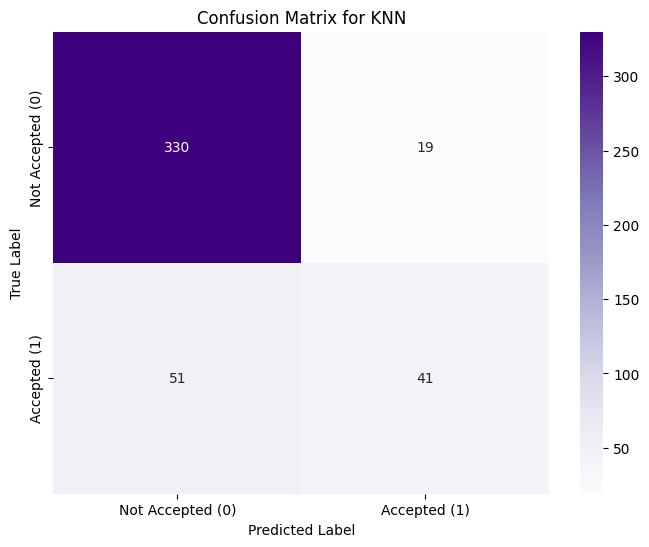

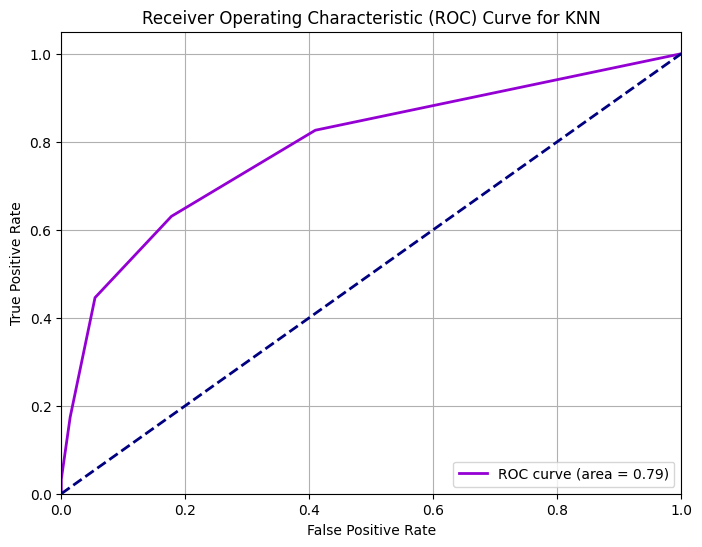

In [25]:
# 4. Making Predictions and Model Evaluation
# We'll use the same classification metrics as for Logistic Regression and Decision Trees.

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test_knn)
y_pred_proba_knn = knn_model.predict_proba(X_test_knn)[:, 1] # Probabilities for the positive class

# Evaluate the model
accuracy_knn = accuracy_score(y_test_knn, y_pred_knn)
precision_knn = precision_score(y_test_knn, y_pred_knn)
recall_knn = recall_score(y_test_knn, y_pred_knn)
f1_knn = f1_score(y_test_knn, y_pred_knn)
conf_matrix_knn = confusion_matrix(y_test_knn, y_pred_knn)
roc_auc_knn = roc_auc_score(y_test_knn, y_pred_proba_knn)

print("\n--- KNN Model Evaluation ---")
print(f"Accuracy: {accuracy_knn:.2f}")
print(f"Precision: {precision_knn:.2f}")
print(f"Recall: {recall_knn:.2f}")
print(f"F1-Score: {f1_knn:.2f}")
print(f"ROC AUC Score: {roc_auc_knn:.2f}")
print("\nConfusion Matrix:")
print(conf_matrix_knn)

# 5. Visualization of Results

# Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Not Accepted (0)', 'Accepted (1)'],
            yticklabels=['Not Accepted (0)', 'Accepted (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for KNN')
plt.show()

# ROC Curve
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test_knn, y_pred_proba_knn)
plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, color='darkviolet', lw=2, label=f'ROC curve (area = {roc_auc_knn:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for KNN')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Interpretation of K-Nearest Neighbors (KNN) Results

**KNN Working Principle**: KNN is a lazy learning algorithm, meaning it doesn't build a model during training. Instead, it memorizes the entire dataset. When a prediction is needed for a new data point, it finds the 'k' closest data points (neighbors) in the training set and assigns the new point the class label that is most common among its neighbors.

-   **Distance Metric**: The choice of distance metric (e.g., Euclidean, Manhattan) is crucial. Euclidean distance is common.
-   **Feature Scaling**: Since KNN relies on distances, features with larger scales would have a disproportionately large effect on the distance calculation. Therefore, **scaling features (e.g., using `StandardScaler`) is a critical preprocessing step for KNN.**
-   **Choice of 'k'**: The number of neighbors ('k') is a hyperparameter. A small 'k' can make the model sensitive to noise and outliers (high variance, low bias), while a large 'k' can smooth out the decision boundaries but might miss fine-grained patterns (low variance, high bias). Cross-validation is often used to find an optimal 'k'.

**Model Evaluation Metrics**:

-   The classification metrics (Accuracy, Precision, Recall, F1-Score, ROC AUC Score, Confusion Matrix) are interpreted in the same way as for Logistic Regression and Decision Trees. They help us understand how well the KNN model distinguishes between customers who accept campaigns and those who don't. Given the class imbalance, paying attention to Precision, Recall, and F1-Score is particularly important.

**Visualizations**:

-   **Confusion Matrix Heatmap**: This visualization helps to see the count of correct and incorrect classifications, breaking down where the model performs well (True Positives, True Negatives) and where it struggles (False Positives, False Negatives).
-   **ROC Curve**: The ROC curve and AUC score give an overall assessment of the model's ability to discriminate between the two classes across various classification thresholds. A curve closer to the top-left corner, indicates a better model.

In summary, KNN provides a non-linear approach to classification that can capture complex decision boundaries. Its performance is heavily influenced by feature scaling and the choice of 'k'. It's often highly interpretable locally, meaning you can explain why a specific data point was classified a certain way by showing its nearest neighbors. However, it can be computationally expensive for very large datasets during prediction time.

## Chapter Summary and Conclusion

Congratulations, SPARKS students! In this chapter, we have successfully explored four fundamental supervised learning methods, each addressing different types of business problems:

1.  **Linear Regression**: We used this model to predict continuous numerical values, specifically customer `Income`. We learned how to interpret coefficients, understand the impact of different features, and evaluate the model using metrics like MAE, MSE, RMSE, and R-squared. The visualizations of actual vs. predicted values and residuals helped us assess the model's fit and assumptions.

2.  **Logistic Regression**: We applied Logistic Regression to a binary classification problem: predicting whether a customer would `Response` to a marketing campaign. We delved into interpreting log-odds coefficients and evaluated the model's performance using a suite of classification metrics including Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and ROC AUC, understanding their importance, especially in imbalanced datasets.

3.  **Decision Tree**: We utilized a Decision Tree to predict if a customer would accept `AcceptedCmpOverall` (at least one previous campaign). This method provided insights into the underlying decision rules through its tree structure and feature importance, making it highly interpretable for business stakeholders. We evaluated it using the same classification metrics, reinforcing our understanding of their application.

4.  **K-Nearest Neighbors (KNN)**: Finally, we explored KNN for predicting overall campaign acceptance. This instance-based learning algorithm highlighted the importance of feature scaling and the impact of the 'k' parameter. We evaluated its performance using classification metrics, demonstrating how different algorithms approach the same problem from varied perspectives.

### Key Takeaways:

*   **Model Selection**: The choice of model depends heavily on the type of problem (regression vs. classification) and the nature of the data.
*   **Data Preparation**: Preprocessing steps like handling missing values and feature scaling (especially for distance-based algorithms like KNN) are crucial for model performance.
*   **Evaluation Metrics**: Always choose appropriate evaluation metrics based on the problem and dataset characteristics (e.g., R-squared for regression, Precision/Recall/F1 for imbalanced classification).
*   **Interpretability**: Some models (like Linear Regression and Decision Trees) offer clearer insights into feature relationships than others.
*   **Iterative Process**: Machine learning is an iterative process involving data preparation, model training, evaluation, and refinement.

This chapter has provided you with a strong foundation in supervised learning. Keep practicing with different datasets and exploring advanced techniques to further hone your skills. Happy modeling!


--- KNN Model Evaluation ---
Accuracy: 0.84
Precision: 0.68
Recall: 0.45
F1-Score: 0.54
ROC AUC Score: 0.79

Confusion Matrix:
[[330  19]
 [ 51  41]]


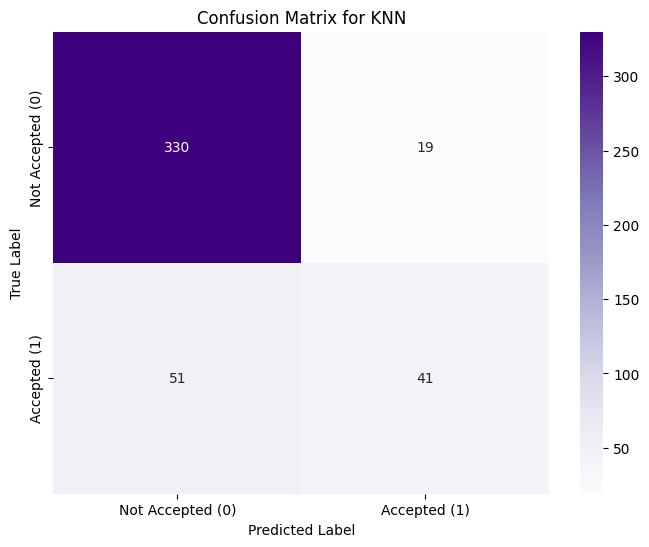

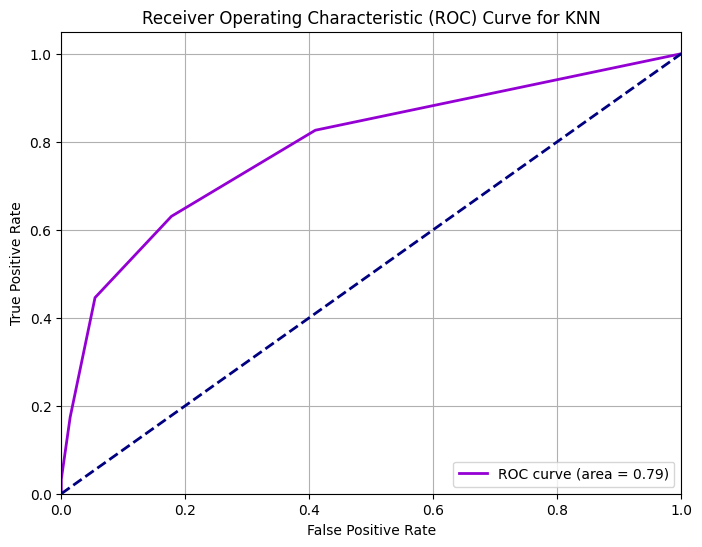

In [22]:
# 4. Making Predictions and Model Evaluation
# We'll use the same classification metrics as for Logistic Regression and Decision Trees.

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test_knn)
y_pred_proba_knn = knn_model.predict_proba(X_test_knn)[:, 1] # Probabilities for the positive class

# Evaluate the model
accuracy_knn = accuracy_score(y_test_knn, y_pred_knn)
precision_knn = precision_score(y_test_knn, y_pred_knn)
recall_knn = recall_score(y_test_knn, y_pred_knn)
f1_knn = f1_score(y_test_knn, y_pred_knn)
conf_matrix_knn = confusion_matrix(y_test_knn, y_pred_knn)
roc_auc_knn = roc_auc_score(y_test_knn, y_pred_proba_knn)

print("\n--- KNN Model Evaluation ---")
print(f"Accuracy: {accuracy_knn:.2f}")
print(f"Precision: {precision_knn:.2f}")
print(f"Recall: {recall_knn:.2f}")
print(f"F1-Score: {f1_knn:.2f}")
print(f"ROC AUC Score: {roc_auc_knn:.2f}")
print("\nConfusion Matrix:")
print(conf_matrix_knn)

# 5. Visualization of Results

# Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Not Accepted (0)', 'Accepted (1)'],
            yticklabels=['Not Accepted (0)', 'Accepted (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for KNN')
plt.show()

# ROC Curve
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test_knn, y_pred_proba_knn)
plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, color='darkviolet', lw=2, label=f'ROC curve (area = {roc_auc_knn:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for KNN')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Interpretation of K-Nearest Neighbors (KNN) Results

**KNN Working Principle**: KNN is a lazy learning algorithm, meaning it doesn't build a model during training. Instead, it memorizes the entire dataset. When a prediction is needed for a new data point, it finds the 'k' closest data points (neighbors) in the training set and assigns the new point the class label that is most common among its neighbors.

-   **Distance Metric**: The choice of distance metric (e.g., Euclidean, Manhattan) is crucial. Euclidean distance is common.
-   **Feature Scaling**: Since KNN relies on distances, features with larger scales would have a disproportionately large effect on the distance calculation. Therefore, **scaling features (e.g., using `StandardScaler`) is a critical preprocessing step for KNN.**
-   **Choice of 'k'**: The number of neighbors ('k') is a hyperparameter. A small 'k' can make the model sensitive to noise and outliers (high variance, low bias), while a large 'k' can smooth out the decision boundaries but might miss fine-grained patterns (low variance, high bias). Cross-validation is often used to find an optimal 'k'.

**Model Evaluation Metrics**:

-   The classification metrics (Accuracy, Precision, Recall, F1-Score, ROC AUC Score, Confusion Matrix) are interpreted in the same way as for Logistic Regression and Decision Trees. They help us understand how well the KNN model distinguishes between customers who accept campaigns and those who don't. Given the class imbalance, paying attention to Precision, Recall, and F1-Score is particularly important.

**Visualizations**:

-   **Confusion Matrix Heatmap**: This visualization helps to see the count of correct and incorrect classifications, breaking down where the model performs well (True Positives, True Negatives) and where it struggles (False Positives, False Negatives).
-   **ROC Curve**: The ROC curve and AUC score give an overall assessment of the model's ability to discriminate between the two classes across various classification thresholds. A curve closer to the top-left corner, indicates a better model.

In summary, KNN provides a non-linear approach to classification that can capture complex decision boundaries. Its performance is heavily influenced by feature scaling and the choice of 'k'. It's often highly interpretable locally, meaning you can explain why a specific data point was classified a certain way by showing its nearest neighbors. However, it can be computationally expensive for very large datasets during prediction time.

## Chapter Summary and Conclusion

Congratulations, SPARKS students! In this chapter, we have successfully explored four fundamental supervised learning methods, each addressing different types of business problems:

1.  **Linear Regression**: We used this model to predict continuous numerical values, specifically customer `Income`. We learned how to interpret coefficients, understand the impact of different features, and evaluate the model using metrics like MAE, MSE, RMSE, and R-squared. The visualizations of actual vs. predicted values and residuals helped us assess the model's fit and assumptions.

2.  **Logistic Regression**: We applied Logistic Regression to a binary classification problem: predicting whether a customer would `Response` to a marketing campaign. We delved into interpreting log-odds coefficients and evaluated the model's performance using a suite of classification metrics including Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and ROC AUC, understanding their importance, especially in imbalanced datasets.

3.  **Decision Tree**: We utilized a Decision Tree to predict if a customer would accept `AcceptedCmpOverall` (at least one previous campaign). This method provided insights into the underlying decision rules through its tree structure and feature importance, making it highly interpretable for business stakeholders. We evaluated it using the same classification metrics, reinforcing our understanding of their application.

4.  **K-Nearest Neighbors (KNN)**: Finally, we explored KNN for predicting overall campaign acceptance. This instance-based learning algorithm highlighted the importance of feature scaling and the impact of the 'k' parameter. We evaluated its performance using classification metrics, demonstrating how different algorithms approach the same problem from varied perspectives.

### Key Takeaways:

*   **Model Selection**: The choice of model depends heavily on the type of problem (regression vs. classification) and the nature of the data.
*   **Data Preparation**: Preprocessing steps like handling missing values and feature scaling (especially for distance-based algorithms like KNN) are crucial for model performance.
*   **Evaluation Metrics**: Always choose appropriate evaluation metrics based on the problem and dataset characteristics (e.g., R-squared for regression, Precision/Recall/F1 for imbalanced classification).
*   **Interpretability**: Some models (like Linear Regression and Decision Trees) offer clearer insights into feature relationships than others.
*   **Iterative Process**: Machine learning is an iterative process involving data preparation, model training, evaluation, and refinement.

This chapter has provided you with a strong foundation in supervised learning. Keep practicing with different datasets and exploring advanced techniques to further hone your skills. Happy modeling!

## Chapter Summary and Conclusion

Congratulations, SPARKS students! In this chapter, we have successfully explored four fundamental supervised learning methods, each addressing different types of business problems:

1.  **Linear Regression**: We used this model to predict continuous numerical values, specifically customer `Income`. We learned how to interpret coefficients, understand the impact of different features, and evaluate the model using metrics like MAE, MSE, RMSE, and R-squared. The visualizations of actual vs. predicted values and residuals helped us assess the model's fit and assumptions.

2.  **Logistic Regression**: We applied Logistic Regression to a binary classification problem: predicting whether a customer would `Response` to a marketing campaign. We delved into interpreting log-odds coefficients and evaluated the model's performance using a suite of classification metrics including Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and ROC AUC, understanding their importance, especially in imbalanced datasets.

3.  **Decision Tree**: We utilized a Decision Tree to predict if a customer would accept `AcceptedCmpOverall` (at least one previous campaign). This method provided insights into the underlying decision rules through its tree structure and feature importance, making it highly interpretable for business stakeholders. We evaluated it using the same classification metrics, reinforcing our understanding of their application.

4.  **K-Nearest Neighbors (KNN)**: Finally, we explored KNN for predicting overall campaign acceptance. This instance-based learning algorithm highlighted the importance of feature scaling and the impact of the 'k' parameter. We evaluated its performance using classification metrics, demonstrating how different algorithms approach the same problem from varied perspectives.

### Key Takeaways:

*   **Model Selection**: The choice of model depends heavily on the type of problem (regression vs. classification) and the nature of the data.
*   **Data Preparation**: Preprocessing steps like handling missing values and feature scaling (especially for distance-based algorithms like KNN) are crucial for model performance.
*   **Evaluation Metrics**: Always choose appropriate evaluation metrics based on the problem and dataset characteristics (e.g., R-squared for regression, Precision/Recall/F1 for imbalanced classification).
*   **Interpretability**: Some models (like Linear Regression and Decision Trees) offer clearer insights into feature relationships than others.
*   **Iterative Process**: Machine learning is an iterative process involving data preparation, model training, evaluation, and refinement.

This chapter has provided you with a strong foundation in supervised learning. Keep practicing with different datasets and exploring advanced techniques to further hone your skills. Happy modeling!

## Chapter Summary and Conclusion

Congratulations, SPARKS students! In this chapter, we have successfully explored four fundamental supervised learning methods, each addressing different types of business problems:

1.  **Linear Regression**: We used this model to predict continuous numerical values, specifically customer `Income`. We learned how to interpret coefficients, understand the impact of different features, and evaluate the model using metrics like MAE, MSE, RMSE, and R-squared. The visualizations of actual vs. predicted values and residuals helped us assess the model's fit and assumptions.

2.  **Logistic Regression**: We applied Logistic Regression to a binary classification problem: predicting whether a customer would `Response` to a marketing campaign. We delved into interpreting log-odds coefficients and evaluated the model's performance using a suite of classification metrics including Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and ROC AUC, understanding their importance, especially in imbalanced datasets.

3.  **Decision Tree**: We utilized a Decision Tree to predict if a customer would accept `AcceptedCmpOverall` (at least one previous campaign). This method provided insights into the underlying decision rules through its tree structure and feature importance, making it highly interpretable for business stakeholders. We evaluated it using the same classification metrics, reinforcing our understanding of their application.

4.  **K-Nearest Neighbors (KNN)**: Finally, we explored KNN for predicting overall campaign acceptance. This instance-based learning algorithm highlighted the importance of feature scaling and the impact of the 'k' parameter. We evaluated its performance using classification metrics, demonstrating how different algorithms approach the same problem from varied perspectives.

### Key Takeaways:

*   **Model Selection**: The choice of model depends heavily on the type of problem (regression vs. classification) and the nature of the data.
*   **Data Preparation**: Preprocessing steps like handling missing values and feature scaling (especially for distance-based algorithms like KNN) are crucial for model performance.
*   **Evaluation Metrics**: Always choose appropriate evaluation metrics based on the problem and dataset characteristics (e.g., R-squared for regression, Precision/Recall/F1 for imbalanced classification).
*   **Interpretability**: Some models (like Linear Regression and Decision Trees) offer clearer insights into feature relationships than others.
*   **Iterative Process**: Machine learning is an iterative process involving data preparation, model training, evaluation, and refinement.

This chapter has provided you with a strong foundation in supervised learning. Keep practicing with different datasets and exploring advanced techniques to further hone your skills. Happy modeling!